# Imports

In [23]:
import numpy as np
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import os

# Gensim
import gensim

# spacy
import spacy

# sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# HuggingFace
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer

# gensim
from gensim.models import Word2Vec

# Word Representations

### Preprocessing

Note: The functions `lemmatization` and `gen_words` were obtained from Tutorial 3: Topic Modelling, Similarity Metrics and LDA.

In [2]:
# Reducing words to their root form (lemmas - refer to chapter 6 of the book)
def lemmatization(texts, allowed_postags = ["NOUN", "ADJ", "VERB", "ADV"]):
    """
    Perform lemmatization on a collection of texts, keeping only specified parts of speech.

    Parameters
    ----------
    texts : list
        A list of strings where each string is a document/text to be lemmatized.
    allowed_postags : list, optional
        A list of strings specifying which parts of speech to keep.
        Default is ["NOUN", "ADJ", "VERB", "ADV"].

    Returns
    -------
    list
        A list of strings where each string contains the lemmatized words
        from the corresponding input text, filtered by part of speech
        and joined with spaces.

    Examples
    --------
    texts = ["I am running quickly to the store"]
    lemmatization(texts)
    ['run quick store']  # Only keeps lemmatized NOUN/ADJ/VERB/ADV
    """

    # We'll be using the spacy library to do the lemmatization
    nlp = spacy.load("en_core_web_sm", disable = ["parser", "ner"])
    texts_out = []
    
    # Process all the texts/docs that you have at once
    for text in tqdm(texts):
        doc = nlp(text)
        new_text = []
        
        for token in doc:
            # Determine if the token part-of-speech is one the things that we specified in "allowed_pos"
            if token.pos_ in allowed_postags:
                # If the token part-of-speech is among the categories which we've specified, then append its lemma (root of the word) to the next_text list 
                new_text.append(token.lemma_)
        # Once you've gone over all the tokens that were part of the doc that you were analyzing, simply attach all the extracted words together (with space in between them) to form this new sentence containing only roots (lemmas) 
        final = " ".join(new_text)
        
        # append the newly created word to the list of processed texts       
        texts_out.append(final)
    
    return texts_out


def gen_words(texts):
    """
    Preprocess a list of texts into tokenized words using Gensim's simple_preprocess.
    
    Parameters:
        texts (list): A list of strings, where each string is a document/text to be processed
    
    Returns:
        list: A list of lists, where each inner list contains preprocessed tokens (words) from the corresponding input text
    
    Example:
        texts = ["Hello, World!", "This is a test-case."]
        gen_words(texts)
        [['hello', 'world'], ['this', 'is', 'a', 'test', 'case']]
    """
    # Preprocesses a list of texts by converting to lowercase, removing punctuation/numbers, and tokenizing into words
    final = []
    for text in texts:
        new = gensim.utils.simple_preprocess(text, deacc=True)
        final.append(new)
        
    return final

### Bag of Words Function

In [3]:
def get_bag_of_words(corpus, bBinary=False):
    if (bBinary):
        vectorizer = CountVectorizer(binary=True)
    else:
        vectorizer = CountVectorizer()
    X = vectorizer.fit_transform(corpus)

    bag_of_words_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out()) # convert to dataFrame
    return bag_of_words_df

In [4]:
def tfidf_transform(train_corpus, test_corpus):
    vectorizer = TfidfVectorizer()
    X_train = vectorizer.fit_transform(train_corpus)
    X_test = vectorizer.transform(test_corpus)
    return X_train, X_test

### Data 

In [5]:
data_dir = os.getcwd()
number_of_rows = 5000

# get plot descriptions
df = pd.read_csv("../../data/output.csv")
plot_descriptions = df["plot"].tolist()
genres = df["genre"].tolist()
movie_Ids = df["movieId"]

# lemmatize plot descriptions
lemmatized_plot_descriptions = lemmatization(plot_descriptions)

# tokenize plot descriptions
tokenized_plot_descriptions = gen_words(lemmatized_plot_descriptions)

# create bag of words representation for each plot description
bag_of_words_plots = get_bag_of_words(lemmatized_plot_descriptions)
bag_of_words_plots[0:5]

100%|██████████| 5456/5456 [00:50<00:00, 108.29it/s]


,1000,10th,11th,12th,13th,14th,15th,1600,168th,16th,...,zebra,zero,zhao,zip,zombie,zone,zoo,zookeeper,zoologist,émile
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# Trained Model
- Logistic Regression Model
- Skip-Gram Word Embeddings

In [6]:
## -- Create Model -- ##
# write out model params
model_params = {
    'sg': 1,       
    'vector_size': 200, 
    'window': 5,     
    'min_count': 4, 
    'workers': 4,
    'seed': 42,
    'epochs': 30,
}
w2v_model = Word2Vec(sentences=tokenized_plot_descriptions, sg=model_params['sg'], vector_size=model_params['vector_size'], window=model_params['window'], min_count=model_params['min_count'], workers=model_params['workers'], seed=model_params['seed'], epochs=model_params['epochs'])

## -- Get Doc Embeddings Vectors -- ##
def get_doc_vectors(tokens, model):
    doc_vecs = [w2v_model.wv[word] for word in tokens if word in w2v_model.wv]
    if not doc_vecs:
        return np.zeros(model.vector_size)
    return np.mean(doc_vecs, axis=0)

## -- Get X and y data -- ## 
X_w2v = np.array([get_doc_vectors(texts, w2v_model) for texts in tokenized_plot_descriptions])
y_w2v = np.array(genres)


## -- Train/Test Split -- ##
X_train_w2v, X_test_w2v, y_train_w2v, y_test_w2v, train_indices, test_indices = train_test_split(X_w2v, y_w2v, np.arange(len(X_w2v)), test_size=0.2, random_state=42)

## -- Train Classifier -- ##
w2v_model = LogisticRegression(max_iter=1000)
w2v_model.fit(X_train_w2v, y_train_w2v)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [17]:
## -- Evaluate -- ##
y_pred_w2v = w2v_model.predict(X_test_w2v)
print(classification_report(y_test_w2v, y_pred_w2v)) 
w2v_f1 = f1_score(y_test_w2v, y_pred_w2v, average='weighted')
w2v_accuracy = accuracy_score(y_test_w2v, y_pred_w2v)

print("################################# Additional Metrics #################################")
print(f"(Weighted) F1 Score: {w2v_f1}")
print(f"Accuracy Score: {w2v_accuracy}")
print("######################################################################################")

              precision    recall  f1-score   support

      Action       0.48      0.59      0.53       145
   Adventure       0.27      0.17      0.21        60
   Animation       1.00      0.06      0.11        18
    Children       0.00      0.00      0.00        25
      Comedy       0.52      0.59      0.55       338
       Crime       0.32      0.12      0.17        69
 Documentary       0.70      0.44      0.54        36
       Drama       0.46      0.60      0.52       293
     Fantasy       0.00      0.00      0.00         2
   Film-Noir       0.00      0.00      0.00         3
      Horror       0.52      0.39      0.45        66
     Musical       0.00      0.00      0.00         6
     Mystery       0.00      0.00      0.00         3
     Romance       0.00      0.00      0.00         6
      Sci-Fi       0.00      0.00      0.00         3
    Thriller       0.00      0.00      0.00         9
         War       0.00      0.00      0.00         1
     Western       0.00    

c:\Users\nourf\anaconda3\envs\python4al3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\nourf\anaconda3\envs\python4al3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\nourf\anaconda3\envs\python4al3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

## Optimize Model

In [8]:
param_grid = {
    "C": [0.1, 0.9, 1, 1.1, 1.15, 1.2],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"],      
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    LogisticRegression(max_iter=2000),
    param_grid,
    cv=cv,
    scoring="f1_weighted",
    n_jobs=-1
)

grid_search.fit(X_train_w2v, y_train_w2v)

print("Best Hyperparameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)
best_logreg_w2v = grid_search.best_estimator_

c:\Users\nourf\anaconda3\envs\python4al3\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\nourf\anaconda3\envs\python4al3\Lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


Best Hyperparameters: {'C': 1.2, 'penalty': 'l2', 'solver': 'liblinear'}
Best Cross-Validation Score: 0.4438838061256785


In [9]:
## -- Get Predictions for Reference Data -- ##
# Find which rows have movieIds in the target range
target_mask = (movie_Ids >= 5046) & (movie_Ids <= 5598)
target_indices = np.where(target_mask)[0]

# Get features and make predictions for these movies
X_target = X_w2v[target_indices]
y_pred_target = w2v_model.predict(X_target)

# Create dataframe with results
target_results_df = pd.DataFrame({'movieId': movie_Ids.iloc[target_indices].values, 'genre': y_pred_target})

# Save to CSV
target_results_df.to_csv("outputs/trained_model_predicted_values.csv", index=False)

OSError: Cannot save file into a non-existent directory: 'outputs'

## Input Variations

### Variation 1: TF-IDF and Additional Postags
- Vectorizer: TFIDF
- Postags: Nouns, Verbs, Adjectives, Adverbs, Proper Nouns

In [10]:
# preprocess data
lemmatized_plot_descriptions2 = lemmatization(plot_descriptions, allowed_postags=["NOUN", "ADJ", "VERB", "ADV", "PROPN"])

tokenized_plot_descriptions2 = gen_words(lemmatized_plot_descriptions2)

X_train_w2v2, X_test_w2v2, y_train_w2v2, y_test_w2v2 = train_test_split(lemmatized_plot_descriptions2, genres,  test_size=0.2, random_state=42)

100%|██████████| 5456/5456 [00:44<00:00, 121.93it/s]


In [11]:
X_train_tfidf, X_test_tfidf = tfidf_transform(X_train_w2v2, X_test_w2v2)

In [18]:
## -- Create Model -- ##
## -- Train Classifier -- ##
w2v_model2 = LogisticRegression(max_iter=1000)
w2v_model2.fit(X_train_tfidf, y_train_w2v2)

## -- Evaluate -- ##
y_pred_w2v2 = w2v_model2.predict(X_test_tfidf)
print(classification_report(y_test_w2v2, y_pred_w2v2))
w2v2_f1 = f1_score(y_test_w2v2, y_pred_w2v2, average='weighted')
w2v2_accuracy = accuracy_score(y_test_w2v2, y_pred_w2v2)
print("################################# Additional Metrics #################################")
print(f"(Weighted) F1 Score: {w2v2_f1}")
print(f"Accuracy Score: {w2v2_accuracy}")
print("######################################################################################")

              precision    recall  f1-score   support

      Action       0.55      0.48      0.51       145
   Adventure       0.00      0.00      0.00        60
   Animation       0.00      0.00      0.00        18
    Children       0.00      0.00      0.00        25
      Comedy       0.47      0.60      0.53       338
       Crime       0.40      0.03      0.05        69
 Documentary       0.50      0.03      0.05        36
       Drama       0.40      0.70      0.51       293
     Fantasy       0.00      0.00      0.00         2
   Film-Noir       0.00      0.00      0.00         3
      Horror       0.75      0.14      0.23        66
     Musical       0.00      0.00      0.00         6
     Mystery       0.00      0.00      0.00         3
     Romance       0.00      0.00      0.00         6
      Sci-Fi       0.00      0.00      0.00         3
    Thriller       0.00      0.00      0.00         9
         War       0.00      0.00      0.00         1
     Western       0.00    

c:\Users\nourf\anaconda3\envs\python4al3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\nourf\anaconda3\envs\python4al3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\nourf\anaconda3\envs\python4al3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

## Variaiton 2: Logistic Regression Model with Pre-trained Word Embeddings

In [13]:
# TODO: Load tokenizer and model
PRETRAINED_MODEL_NAME = "distilbert-base-cased"

tokenizer_pre_1 = AutoTokenizer.from_pretrained(PRETRAINED_MODEL_NAME)
model_pre_1 = AutoModelForSequenceClassification.from_pretrained(PRETRAINED_MODEL_NAME, num_labels=19) 

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 3244.38it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-cased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [14]:
# Split Data
X = df["plot"]
y = df["genre"]
movie_Ids = df["movieId"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# create label encoder
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)
mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Label Mapping:", mapping)

# create dictionaries
train_dict = {"text": X_train.tolist(), "labels": y_train_enc.tolist()}
test_dict  = {"text": X_test.tolist(), "labels": y_test_enc.tolist()}  

train_dataset = Dataset.from_dict(train_dict)
test_dataset  = Dataset.from_dict(test_dict)

def tokenize(example):
    return tokenizer_pre_1(example["text"], padding="max_length", truncation=True)

# encode data
encoded_X_pre_1 = train_dataset.map(tokenize, batched=True)
encoded_X_test_pre_1 = test_dataset.map(tokenize, batched=True)

encoded_X_pre_1 = encoded_X_pre_1.remove_columns(["text"])
encoded_X_test_pre_1 = encoded_X_test_pre_1.remove_columns(["text"])

encoded_X_pre_1.set_format("torch")
encoded_X_test_pre_1.set_format("torch")

print(encoded_X_pre_1[0])

Label Mapping: {'Action': 0, 'Adventure': 1, 'Animation': 2, 'Children': 3, 'Comedy': 4, 'Crime': 5, 'Documentary': 6, 'Drama': 7, 'Fantasy': 8, 'Film-Noir': 9, 'Horror': 10, 'IMAX': 11, 'Musical': 12, 'Mystery': 13, 'Romance': 14, 'Sci-Fi': 15, 'Thriller': 16, 'War': 17, 'Western': 18}


Map: 100%|██████████| 1092/1092 [00:00<00:00, 1588.16 examples/s]

{'labels': tensor(7), 'input_ids': tensor([  101,   138,  3907,  4887,  1107,  1567,  1114,   170,  7198,  1685,
         1590,  1119, 20052,   117,  1133,  1177,  1674,  1117,  1488,   119,
          102,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0, 

In [15]:
# Training arguments for Pre-trained Model 1

training_args_pre_1 = TrainingArguments(output_dir="./training_checkpoints/distilbert-base", num_train_epochs=3) # fix output directory
trainer_pre_1 = Trainer(
    model=model_pre_1,
    args=training_args_pre_1,
    train_dataset=encoded_X_pre_1,
    eval_dataset=encoded_X_test_pre_1,
)

trainer_pre_1.train()

Step,Training Loss
500,1.698283
1000,1.139931
1500,0.708196


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.86it/s]


TrainOutput(global_step=1638, training_loss=1.1424776666475884, metrics={'train_runtime': 1679.4331, 'train_samples_per_second': 7.795, 'train_steps_per_second': 0.975, 'total_flos': 1734788961275904.0, 'train_loss': 1.1424776666475884, 'epoch': 3.0})

In [16]:
# Evaluate the model on the test set
predictions_pre_1 = trainer_pre_1.predict(encoded_X_test_pre_1)
y_pred_pre_1 = np.argmax(predictions_pre_1.predictions, axis=-1)
y_pred_indices = predictions_pre_1.predictions.argmax(axis=1)
y_pred_pre_1 = label_encoder.inverse_transform(y_pred_indices) # Decode integer predictions 
print(classification_report(y_test, y_pred_pre_1))

# store metric for later comparison
f1_score_pre_1 = f1_score(y_test, y_pred_pre_1, average='weighted')
accuracy_score_pre_1 = accuracy_score(y_test, y_pred_pre_1)

print("################################# Additional Metrics #################################")
print(f"(Weighted) F1 Score: {f1_score_pre_1}")
print(f"Accuracy Score: {accuracy_score_pre_1}")
print("######################################################################################")

              precision    recall  f1-score   support

      Action       0.55      0.62      0.58       145
   Adventure       0.36      0.43      0.39        60
   Animation       0.00      0.00      0.00        18
    Children       0.64      0.28      0.39        25
      Comedy       0.62      0.58      0.60       338
       Crime       0.40      0.46      0.43        69
 Documentary       0.77      0.67      0.72        36
       Drama       0.53      0.63      0.58       293
     Fantasy       0.00      0.00      0.00         2
   Film-Noir       0.00      0.00      0.00         3
      Horror       0.57      0.59      0.58        66
     Musical       0.00      0.00      0.00         6
     Mystery       0.00      0.00      0.00         3
     Romance       0.00      0.00      0.00         6
      Sci-Fi       0.00      0.00      0.00         3
    Thriller       0.00      0.00      0.00         9
         War       0.00      0.00      0.00         1
     Western       1.00    

c:\Users\nourf\anaconda3\envs\python4al3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\nourf\anaconda3\envs\python4al3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\nourf\anaconda3\envs\python4al3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

# Compare Results

## Table of F1 and Accuracy Scores

In [21]:
results = {
    "Model": [
        f"Logistic Regression with Skip-gram",
        f"Logistic Regression with TF-IDF",
        f"Logistic Regression with DistilBERT",
    ],
    "F1 (Weighted)": [w2v_f1, w2v2_f1, f1_score_pre_1],
     "Accuracy": [w2v_accuracy, w2v2_accuracy, accuracy_score_pre_1],
}

results_df = pd.DataFrame(results)
results_df

,Model,F1 (Weighted),Accuracy
0,Logistic Regression with Skip-gram,0.448931,0.478938
1,Logistic Regression with TF-IDF,0.387123,0.448718
2,Logistic Regression with DistilBERT,0.534864,0.548535


In [27]:
# Save Results as PNG
fig, ax = plt.subplots(figsize=(10, 2))
ax.axis('off')
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)
table = pd.plotting.table(ax, results_df, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
plt.savefig('./logistic-regression-output/model-scores.png', bbox_inches='tight', dpi=150)
plt.close()

## Confusion Matrices

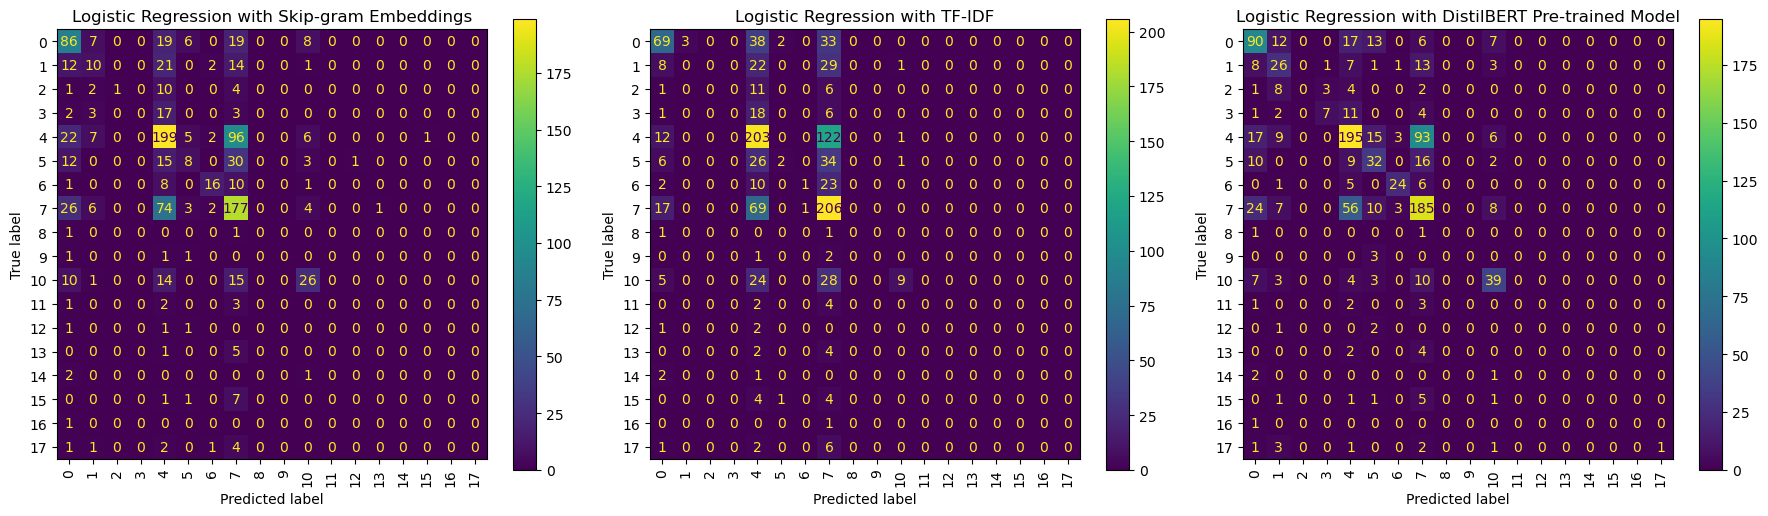

In [28]:
fig, axes = plt.subplots(1,3, figsize=(18, 5))

models_to_plot = [
    (y_test_w2v, y_pred_w2v, "Logistic Regression with Skip-gram Embeddings"),
    (y_test_w2v2, y_pred_w2v2, "Logistic Regression with TF-IDF"),
    (y_test, y_pred_pre_1, "Logistic Regression with DistilBERT Pre-trained Model"),
]

for ax, (y_true, y_pred_vals, title) in zip(axes, models_to_plot):
    cm = confusion_matrix(y_true, y_pred_vals)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, xticks_rotation=90)
    ax.set_title(title)
plt.tight_layout()
plt.savefig("./logistic-regression-output/confusion_matrices.png", dpi=300, bbox_inches="tight")
plt.show()